# Energy Consumption Analysis in Smart Buildings

**Goal:** Identify energy usage patterns across buildings and group them by consumption behavior to support energy-optimization decisions.

**Data:** ASHRAE Great Energy Predictor III — hourly meter readings, building metadata, and site-level weather data.

**Pipeline:**
1. Data loading & merging (meter + building + weather)
2. Preprocessing (missing values, timestamps)
3. Feature engineering (time features, per-building behavioral features)
4. Exploratory data analysis
5. Weather impact analysis
6. Dimensionality reduction with PCA
7. K-Means clustering of buildings
8. Cluster profiling & energy-optimization insights

## 1. Data Loading

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
path = "/kaggle/input/competitions/ashrae-energy-prediction/"

building = pd.read_csv(path + "building_metadata.csv")
test     = pd.read_csv(path + "test.csv")
train    = pd.read_csv(path + "train.csv")
wtrain   = pd.read_csv(path + "weather_train.csv")
wtest    = pd.read_csv(path + "weather_test.csv")

In [6]:
building

,site_id,building_id,primary_use,square_feet,year_built,floor_count
0,0,0,Education,7432,2008.0,NaN
1,0,1,Education,2720,2004.0,NaN
2,0,2,Education,5376,1991.0,NaN
3,0,3,Education,23685,2002.0,NaN
4,0,4,Education,116607,1975.0,NaN
...,...,...,...,...,...,...
1444,15,1444,Entertainment/public assembly,19619,1914.0,NaN
1445,15,1445,Education,4298,NaN,NaN
1446,15,1446,Entertainment/public assembly,11265,1997.0,NaN
1447,15,1447,Lodging/residential,29775,2001.0,NaN


In [7]:
test

,row_id,building_id,meter,timestamp
0,0,0,0,2017-01-01 00:00:00
1,1,1,0,2017-01-01 00:00:00
2,2,2,0,2017-01-01 00:00:00
3,3,3,0,2017-01-01 00:00:00
4,4,4,0,2017-01-01 00:00:00
...,...,...,...,...
41697595,41697595,1444,0,2018-05-09 07:00:00
41697596,41697596,1445,0,2018-05-09 07:00:00
41697597,41697597,1446,0,2018-05-09 07:00:00
41697598,41697598,1447,0,2018-05-09 07:00:00


In [8]:
train

,building_id,meter,timestamp,meter_reading
0,0,0,2016-01-01 00:00:00,0.000
1,1,0,2016-01-01 00:00:00,0.000
2,2,0,2016-01-01 00:00:00,0.000
3,3,0,2016-01-01 00:00:00,0.000
4,4,0,2016-01-01 00:00:00,0.000
...,...,...,...,...
20216095,1444,0,2016-12-31 23:00:00,8.750
20216096,1445,0,2016-12-31 23:00:00,4.825
20216097,1446,0,2016-12-31 23:00:00,0.000
20216098,1447,0,2016-12-31 23:00:00,159.575


In [9]:
wtrain

,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,2016-01-01 00:00:00,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,0,2016-01-01 01:00:00,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5
2,0,2016-01-01 02:00:00,22.8,2.0,21.1,0.0,1020.2,0.0,0.0
3,0,2016-01-01 03:00:00,21.1,2.0,20.6,0.0,1020.1,0.0,0.0
4,0,2016-01-01 04:00:00,20.0,2.0,20.0,-1.0,1020.0,250.0,2.6
...,...,...,...,...,...,...,...,...,...
139768,15,2016-12-31 19:00:00,3.0,NaN,-8.0,NaN,NaN,180.0,5.7
139769,15,2016-12-31 20:00:00,2.8,2.0,-8.9,NaN,1007.4,180.0,7.7
139770,15,2016-12-31 21:00:00,2.8,NaN,-7.2,NaN,1007.5,180.0,5.1
139771,15,2016-12-31 22:00:00,2.2,NaN,-6.7,NaN,1008.0,170.0,4.6


In [10]:
wtest

,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,2017-01-01 00:00:00,17.8,4.0,11.7,NaN,1021.4,100.0,3.6
1,0,2017-01-01 01:00:00,17.8,2.0,12.8,0.0,1022.0,130.0,3.1
2,0,2017-01-01 02:00:00,16.1,0.0,12.8,0.0,1021.9,140.0,3.1
3,0,2017-01-01 03:00:00,17.2,0.0,13.3,0.0,1022.2,140.0,3.1
4,0,2017-01-01 04:00:00,16.7,2.0,13.3,0.0,1022.3,130.0,2.6
...,...,...,...,...,...,...,...,...,...
277238,15,2018-12-31 19:00:00,3.3,NaN,1.7,NaN,1018.3,150.0,7.7
277239,15,2018-12-31 20:00:00,2.8,NaN,1.1,NaN,1017.8,140.0,5.1
277240,15,2018-12-31 21:00:00,2.8,NaN,1.7,-1.0,1017.2,140.0,6.2
277241,15,2018-12-31 22:00:00,2.8,NaN,2.2,8.0,1016.1,140.0,5.1


## 2. Preprocessing

Weather gaps are interpolated **per site, in time order, before merging**, so values are never filled using readings from a different site.

In [11]:
weather_cols = [
    'air_temperature', 'cloud_coverage', 'dew_temperature',
    'precip_depth_1_hr', 'sea_level_pressure',
    'wind_direction', 'wind_speed'
]

for w in (wtrain, wtest):
    w.sort_values(['site_id', 'timestamp'], inplace=True)
    w[weather_cols] = (
        w.groupby('site_id')[weather_cols]
         .transform(lambda s: s.interpolate(limit_direction='both'))
    )

wtrain.isna().mean()

site_id               0.000000
timestamp             0.000000
air_temperature       0.000000
cloud_coverage        0.123257
dew_temperature       0.000000
precip_depth_1_hr     0.187969
sea_level_pressure    0.062637
wind_direction        0.000000
wind_speed            0.000000
dtype: float64

In [12]:
train2 = train.merge(building, on='building_id', how='left')
test2 = test.merge(building, on='building_id', how='left')

train2 = train2.merge(wtrain, on=['site_id', 'timestamp'], how='left')
test2 = test2.merge(wtest, on=['site_id', 'timestamp'], how='left')

In [13]:
train2["timestamp"] = pd.to_datetime(train2["timestamp"])
test2["timestamp"] = pd.to_datetime(test2["timestamp"])

In [14]:
train2

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,2016-01-01 00:00:00,0.000,0,Education,7432,2008.0,NaN,25.0,6.0,20.0,-1.0,1019.7,0.0,0.0
1,1,0,2016-01-01 00:00:00,0.000,0,Education,2720,2004.0,NaN,25.0,6.0,20.0,-1.0,1019.7,0.0,0.0
2,2,0,2016-01-01 00:00:00,0.000,0,Education,5376,1991.0,NaN,25.0,6.0,20.0,-1.0,1019.7,0.0,0.0
3,3,0,2016-01-01 00:00:00,0.000,0,Education,23685,2002.0,NaN,25.0,6.0,20.0,-1.0,1019.7,0.0,0.0
4,4,0,2016-01-01 00:00:00,0.000,0,Education,116607,1975.0,NaN,25.0,6.0,20.0,-1.0,1019.7,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20216095,1444,0,2016-12-31 23:00:00,8.750,15,Entertainment/public assembly,19619,1914.0,NaN,1.7,2.0,-5.6,-1.0,1008.5,180.0,8.8
20216096,1445,0,2016-12-31 23:00:00,4.825,15,Education,4298,NaN,NaN,1.7,2.0,-5.6,-1.0,1008.5,180.0,8.8
20216097,1446,0,2016-12-31 23:00:00,0.000,15,Entertainment/public assembly,11265,1997.0,NaN,1.7,2.0,-5.6,-1.0,1008.5,180.0,8.8
20216098,1447,0,2016-12-31 23:00:00,159.575,15,Lodging/residential,29775,2001.0,NaN,1.7,2.0,-5.6,-1.0,1008.5,180.0,8.8


### Data availability (train vs test)

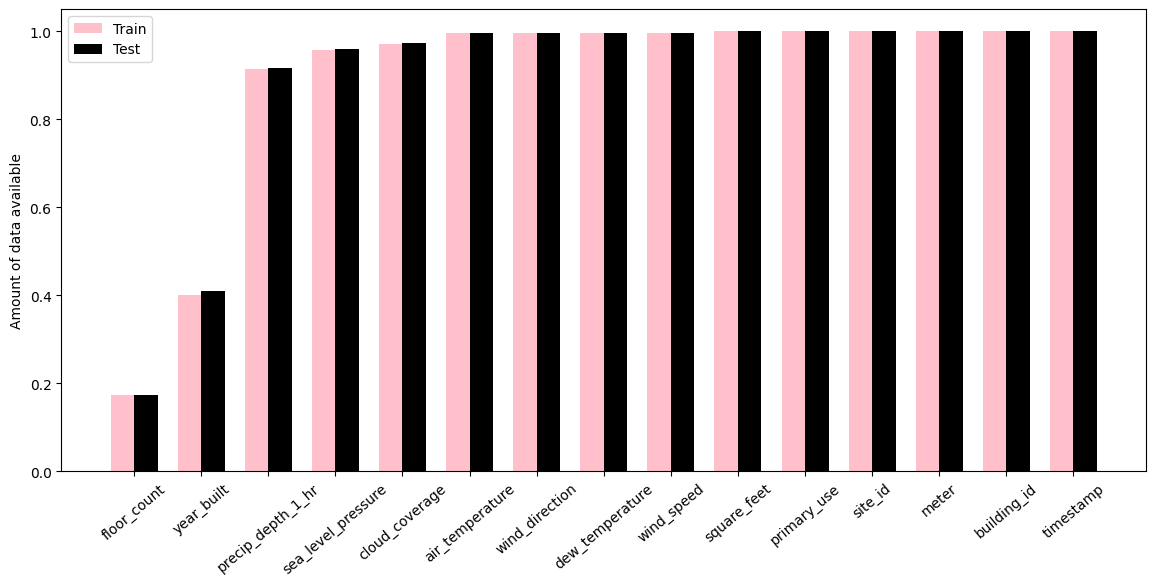

In [15]:
train_data = (train2.count() / len(train2)).drop('meter_reading').sort_values().values
ind = np.arange(len(train_data))
width = 0.35

fig, axes = plt.subplots(1,1,figsize=(14, 6), dpi=100)
tr = axes.bar(ind, train_data, width, color='pink')

test_data = (test2.count() / len(test2)).drop('row_id').sort_values().values
tt = axes.bar(ind+width, test_data, width, color='black')

axes.set_ylabel('Amount of data available');
axes.set_xticks(ind + width / 2)
axes.set_xticklabels((train2.count() / len(train2)).drop('meter_reading').sort_values().index, rotation=40)
axes.legend([tr, tt], ['Train', 'Test']);

In [16]:
train2['square_feet'] = train2['square_feet'].fillna(
    train2['square_feet'].median()
)

train2 = train2.dropna(subset=['meter_reading'])

## 3. Feature Engineering

### Time features

In [17]:
train2['hour'] = train2['timestamp'].dt.hour
train2['dayofweek'] = train2['timestamp'].dt.dayofweek
train2['is_weekend'] = train2['dayofweek'].isin([5,6]).astype(int)

In [18]:
train2['is_day'] = train2['hour'].between(8,18).astype(int)

### Per-building behavioral features

- **mean / peak / std load** – overall consumption level and variability
- **load_factor** = mean / peak – how flat vs. peaky the demand is (low = peaky)
- **day_night_ratio** – dependence on working hours
- **weekend_weekday_ratio** – dependence on the weekly schedule

In [19]:
import warnings
warnings.filterwarnings("ignore")
building_features = train2.groupby('building_id').apply(
    lambda x: pd.Series({

        'mean_load': x['meter_reading'].mean(),
        'peak_load': x['meter_reading'].max(),
        'load_std': x['meter_reading'].std(),

        'square_feet': x['square_feet'].iloc[0],

        'load_factor': x['meter_reading'].mean() / x['meter_reading'].max(),

        'day_mean': x.loc[x['is_day']==1, 'meter_reading'].mean(),
        'night_mean': x.loc[x['is_day']==0, 'meter_reading'].mean(),

        'weekend_mean': x.loc[x['is_weekend']==1, 'meter_reading'].mean(),
        'weekday_mean': x.loc[x['is_weekend']==0, 'meter_reading'].mean(),
    })
)

building_features['day_night_ratio'] = (
    building_features['day_mean'] /
    building_features['night_mean']
)

building_features['weekend_weekday_ratio'] = (
    building_features['weekend_mean'] /
    building_features['weekday_mean']
)

building_features = building_features.dropna()
load_cols = [
    'mean_load',
    'peak_load',
    'load_std',
    'day_mean',
    'night_mean',
    'weekend_mean',
    'weekday_mean'
]

building_features.describe()

,mean_load,peak_load,load_std,square_feet,load_factor,day_mean,night_mean,weekend_mean,weekday_mean,day_night_ratio,weekend_weekday_ratio
count,1.449000e+03,1.449000e+03,1.449000e+03,1449.000000,1449.000000,1.449000e+03,1.449000e+03,1.449000e+03,1.449000e+03,1449.000000,1449.000000
mean,1.652311e+03,1.907832e+04,3.768607e+03,92111.776398,0.293549,1.700004e+03,1.611944e+03,1.434616e+03,1.739888e+03,1.316771,0.861198
std,5.011525e+04,5.760565e+05,1.270355e+05,110769.950997,0.187276,5.094405e+04,4.941390e+04,4.262006e+04,5.313118e+04,0.501624,0.173679
min,3.999772e-04,4.000000e-04,2.133948e-06,283.000000,0.002673,4.000000e-04,3.999580e-04,4.000000e-04,3.999681e-04,0.116676,0.101821
25%,3.204824e+01,9.351000e+01,1.354195e+01,23012.000000,0.137159,3.595810e+01,2.671647e+01,2.594839e+01,3.347609e+01,1.021604,0.801181
50%,9.409627e+01,3.382500e+02,5.040389e+01,57673.000000,0.280978,1.050254e+02,8.512173e+01,8.246927e+01,9.853991e+01,1.168263,0.907975
75%,2.569278e+02,1.923580e+03,2.101125e+02,115676.000000,0.426288,2.892496e+02,2.332864e+02,2.342936e+02,2.598768e+02,1.440242,0.974496
max,1.907446e+06,2.190470e+07,4.834351e+06,875000.000000,0.999943,1.938990e+06,1.880750e+06,1.622056e+06,2.022276e+06,6.044846,2.344820


### Log transform
Load values are heavily right-skewed, so a log transform is applied before scaling.

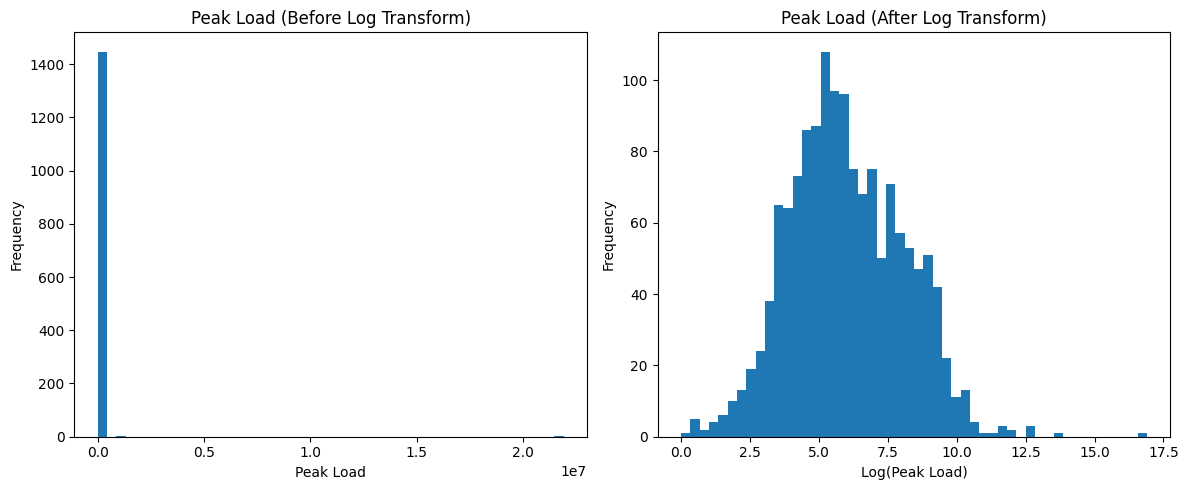

In [20]:
import matplotlib.pyplot as plt
import numpy as np

feature = building_features['peak_load']

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(feature, bins=50)
plt.title("Peak Load (Before Log Transform)")
plt.xlabel("Peak Load")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(np.log1p(feature), bins=50)
plt.title("Peak Load (After Log Transform)")
plt.xlabel("Log(Peak Load)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [21]:
for col in load_cols:
    building_features[col] = np.log1p(building_features[col])

building_features

,mean_load,peak_load,load_std,square_feet,load_factor,day_mean,night_mean,weekend_mean,weekday_mean,day_night_ratio,weekend_weekday_ratio
building_id,,,,,,,,,,,
0,4.993523,6.107023,4.811348,7432.0,0.326908,4.988258,4.997956,4.988234,4.995643,0.990283,0.992568
1,4.328961,5.545177,4.139404,2720.0,0.293590,4.346294,4.314056,4.340070,4.324456,1.033208,1.015948
2,2.744150,4.233860,2.836959,5376.0,0.214044,3.028917,2.417356,2.637579,2.784012,1.925852,0.854812
3,5.466159,6.843750,5.332650,23685.0,0.251387,5.488068,5.447239,5.432660,5.479326,1.041854,0.954215
4,6.885056,8.186743,6.660183,116607.0,0.271870,6.922170,6.852540,6.860855,6.894630,1.072187,0.966756
...,...,...,...,...,...,...,...,...,...,...,...
1444,2.137961,3.606177,1.683879,19619.0,0.208852,2.014126,2.231459,2.156716,2.130425,0.781166,1.030231
1445,1.746207,2.472328,0.840562,4298.0,0.436204,1.800634,1.697857,1.748272,1.745380,1.132501,1.003509
1446,1.524351,2.791165,1.710548,11265.0,0.234782,1.946832,0.937399,0.777885,1.715077,3.866819,0.258248


In [22]:
building_features.describe()

,mean_load,peak_load,load_std,square_feet,load_factor,day_mean,night_mean,weekend_mean,weekday_mean,day_night_ratio,weekend_weekday_ratio
count,1449.000000,1449.000000,1449.000000,1449.000000,1449.000000,1449.000000,1449.000000,1449.000000,1449.000000,1449.000000,1449.000000
mean,4.514357,6.015061,4.088075,92111.776398,0.293549,4.613272,4.400801,4.388839,4.554559,1.316771,0.861198
std,1.629976,2.075918,1.853974,110769.950997,0.187276,1.628093,1.654002,1.672602,1.622239,0.501624,0.173679
min,0.000400,0.000400,0.000002,283.000000,0.002673,0.000400,0.000400,0.000400,0.000400,0.116676,0.101821
25%,3.497968,4.548706,2.677038,23012.000000,0.137159,3.609785,3.322027,3.293923,3.540266,1.021604,0.801181
50%,4.554890,5.826737,3.939714,57673.000000,0.280978,4.663678,4.455762,4.424478,4.600559,1.168263,0.907975
75%,5.552680,7.562463,5.352391,115676.000000,0.426288,5.670741,5.456544,5.460834,5.564048,1.440242,0.974496
max,14.461276,16.902212,15.391258,875000.000000,0.999943,14.477678,14.447181,14.299205,14.519735,6.044846,2.344820


In [23]:
building_features.sort_values('day_mean', ascending=False).head()

,mean_load,peak_load,load_std,square_feet,load_factor,day_mean,night_mean,weekend_mean,weekday_mean,day_night_ratio,weekend_weekday_ratio
building_id,,,,,,,,,,,
1099,14.461276,16.902212,15.391258,332884.0,0.087079,14.477678,14.447181,14.299205,14.519735,1.030966,0.802094
778,10.170559,13.688103,11.667328,108339.0,0.029671,10.204488,10.140919,10.160254,10.174651,1.065636,0.985705
1197,10.008894,11.769512,10.234744,50552.0,0.171932,10.013101,10.005320,9.983861,10.018790,1.007811,0.965673
1168,9.706638,11.787720,10.167309,577101.0,0.124788,9.739643,9.677827,9.640312,9.732115,1.063771,0.912279
1159,9.392050,11.519116,9.863673,671507.0,0.119178,9.448459,9.341706,9.350592,9.408238,1.112668,0.943979


## 4. Exploratory Data Analysis

In [24]:
train2['timestamp'] = pd.to_datetime(train2['timestamp'])

train2['hour'] = train2['timestamp'].dt.hour
train2['dayofweek'] = train2['timestamp'].dt.dayofweek
train2['is_weekend'] = train2['dayofweek'].isin([5,6])
hourly_pattern = (
    train2.groupby('hour')['meter_reading']
    .mean()
)

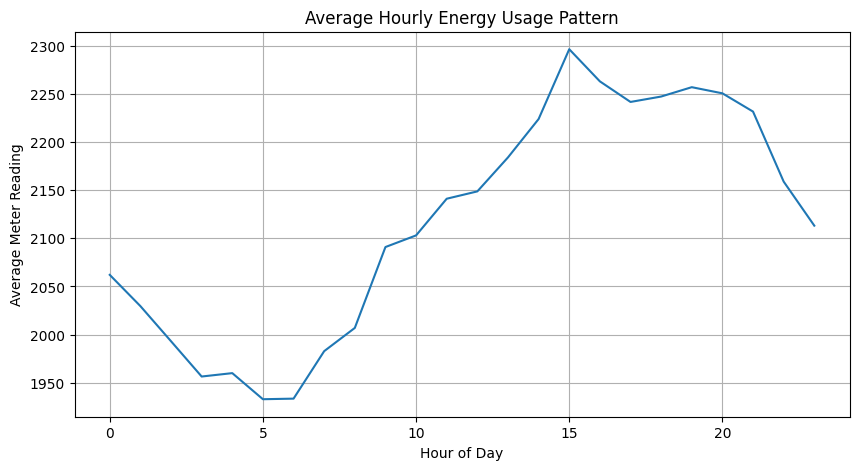

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(hourly_pattern.index, hourly_pattern.values)
plt.xlabel("Hour of Day")
plt.ylabel("Average Meter Reading")
plt.title("Average Hourly Energy Usage Pattern")
plt.grid(True)
plt.show()

In [26]:
weekday_pattern = (
    train2[~train2['is_weekend']]
    .groupby('hour')['meter_reading']
    .mean()
)

weekend_pattern = (
    train2[train2['is_weekend']]
    .groupby('hour')['meter_reading']
    .mean()
)

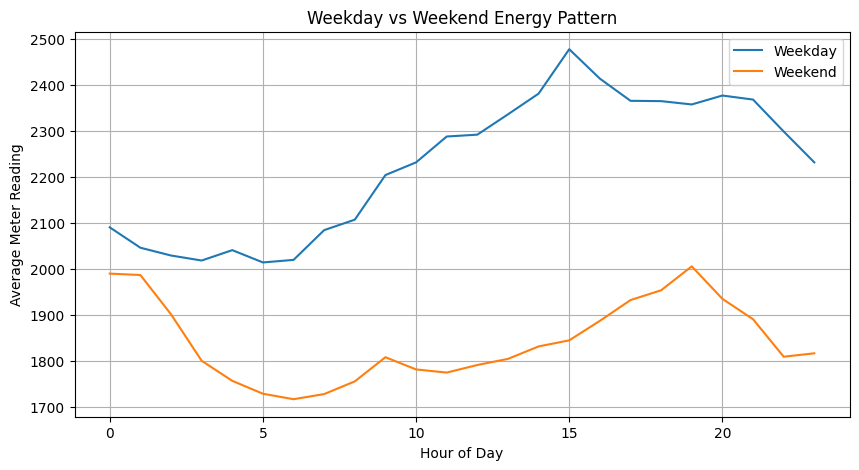

In [27]:
plt.figure(figsize=(10,5))

plt.plot(weekday_pattern.index, weekday_pattern.values, label="Weekday")
plt.plot(weekend_pattern.index, weekend_pattern.values, label="Weekend")

plt.xlabel("Hour of Day")
plt.ylabel("Average Meter Reading")
plt.title("Weekday vs Weekend Energy Pattern")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
weekday_avg = train2[~train2['is_weekend']]['meter_reading'].mean()
weekend_avg = train2[train2['is_weekend']]['meter_reading'].mean()

print("Weekday Average:", weekday_avg)
print("Weekend Average:", weekend_avg)
print("Ratio (Weekend/Weekday):", weekend_avg / weekday_avg)

Weekday Average: 2227.0251583721833
Weekend Average: 1843.4238336277192
Ratio (Weekend/Weekday): 0.8277516878054252


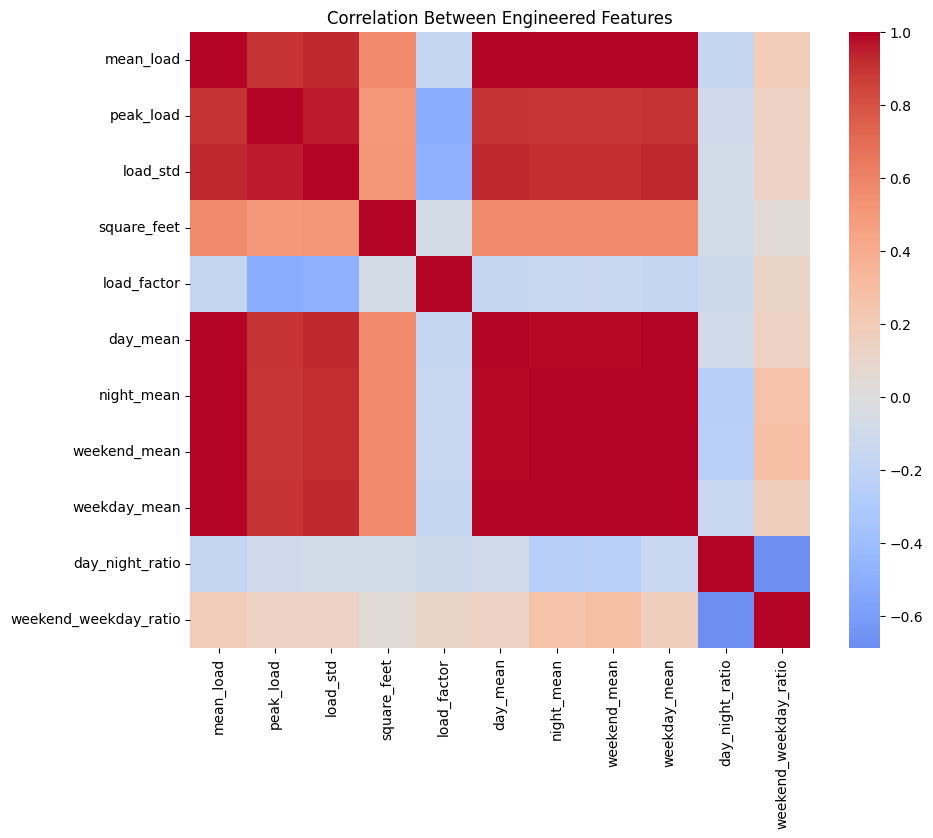

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(building_features.corr(),
            cmap='coolwarm',
            center=0,
            annot=False)

plt.title("Correlation Between Engineered Features")
plt.show()

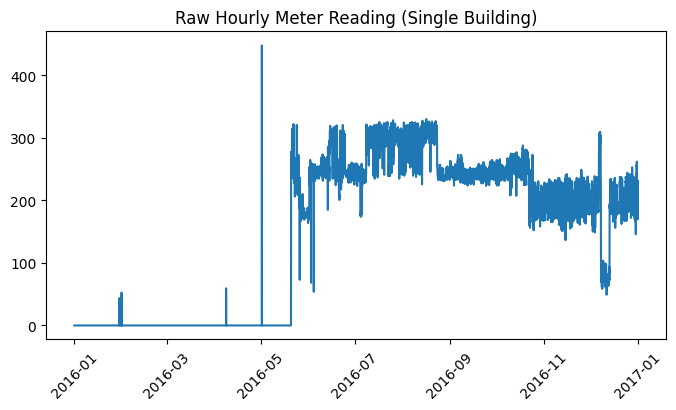

In [30]:
sample_building = train2[train2['building_id'] == train2['building_id'].iloc[0]]

plt.figure(figsize=(8,4))
plt.plot(sample_building['timestamp'], sample_building['meter_reading'])
plt.title("Raw Hourly Meter Reading (Single Building)")
plt.xticks(rotation=45)
plt.show()

## 5. Weather Impact Analysis

How does outdoor weather relate to energy consumption? Readings are aggregated to **daily** level to reduce hourly noise.

wind_speed           -0.100124
sea_level_pressure   -0.048067
cloud_coverage       -0.045835
dew_temperature      -0.020679
air_temperature       0.014631
precip_depth_1_hr     0.017833
Name: load, dtype: float64


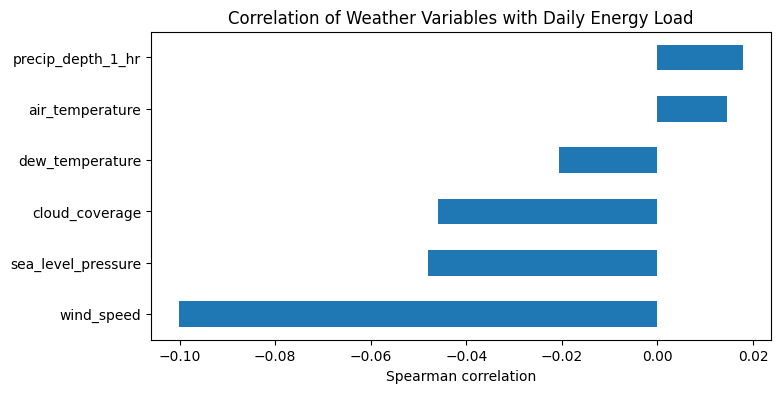

In [31]:
daily = (
    train2
    .groupby(['building_id', pd.Grouper(key='timestamp', freq='D')])
    .agg(load=('meter_reading', 'mean'),
         air_temperature=('air_temperature', 'mean'),
         dew_temperature=('dew_temperature', 'mean'),
         cloud_coverage=('cloud_coverage', 'mean'),
         wind_speed=('wind_speed', 'mean'),
         precip_depth_1_hr=('precip_depth_1_hr', 'mean'),
         sea_level_pressure=('sea_level_pressure', 'mean'))
    .reset_index()
)

# Spearman is rank-based, so it is robust to the very different load scales across buildings
weather_corr = (
    daily.drop(columns=['building_id', 'timestamp'])
         .corr(method='spearman')['load']
         .drop('load')
         .sort_values()
)
print(weather_corr)

plt.figure(figsize=(8,4))
weather_corr.plot(kind='barh')
plt.title("Correlation of Weather Variables with Daily Energy Load")
plt.xlabel("Spearman correlation")
plt.show()

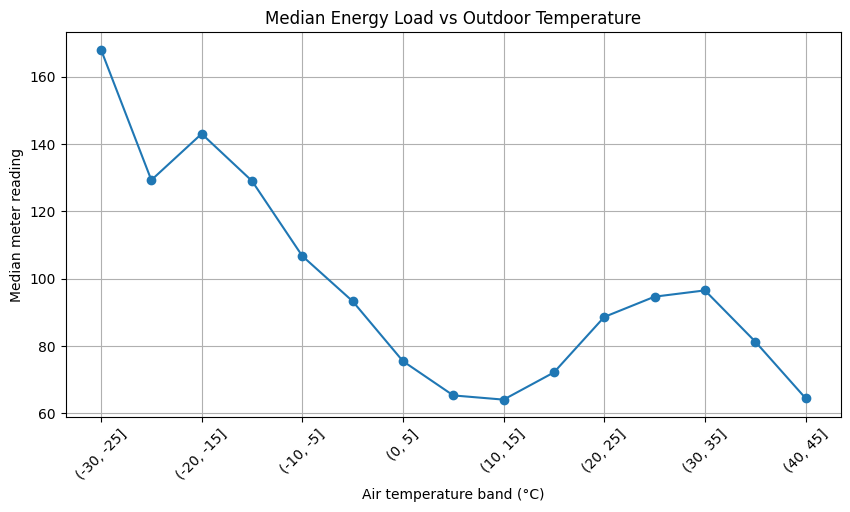

In [32]:
# Average load by outdoor temperature band
train2['temp_bin'] = pd.cut(train2['air_temperature'], bins=range(-30, 50, 5))
temp_load = train2.groupby('temp_bin', observed=True)['meter_reading'].median()

plt.figure(figsize=(10,5))
temp_load.plot(marker='o')
plt.title("Median Energy Load vs Outdoor Temperature")
plt.xlabel("Air temperature band (°C)")
plt.ylabel("Median meter reading")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

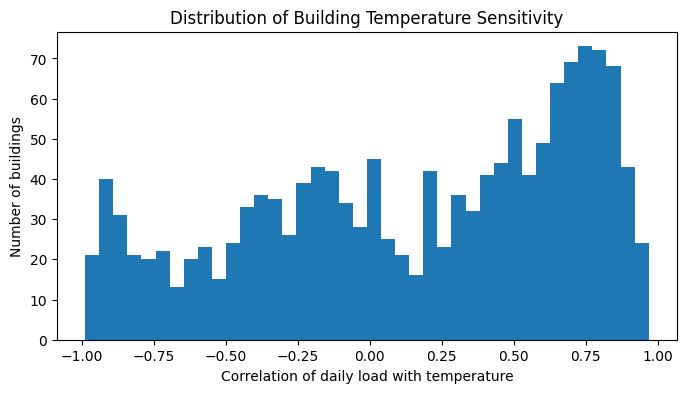

Cooling-driven buildings (corr > 0.5): 532
Heating-driven buildings (corr < -0.5): 226


In [33]:
# Temperature sensitivity of each building = correlation of its daily load with daily temperature
building_temp_sens = (
    daily.groupby('building_id')
         .apply(lambda d: d['load'].corr(d['air_temperature'], method='spearman'))
         .rename('temp_sensitivity')
)

plt.figure(figsize=(8,4))
plt.hist(building_temp_sens.dropna(), bins=40)
plt.title("Distribution of Building Temperature Sensitivity")
plt.xlabel("Correlation of daily load with temperature")
plt.ylabel("Number of buildings")
plt.show()

print("Cooling-driven buildings (corr > 0.5):", (building_temp_sens > 0.5).sum())
print("Heating-driven buildings (corr < -0.5):", (building_temp_sens < -0.5).sum())

## 6. Dimensionality Reduction (PCA)

Clustering uses **behavioral features only**. `square_feet` is excluded so buildings are grouped by *how* they consume energy, not just how big they are. It is kept aside for profiling the clusters afterwards.

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

behavior_features = building_features.drop(columns=['square_feet'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(behavior_features)

pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)

print("Number of input features:", X_scaled.shape[1])
print("Components selected:", pca.n_components_)
print("Explained variance:", pca.explained_variance_ratio_)
print("Total variance retained:", pca.explained_variance_ratio_.sum())

Number of input features: 10
Components selected: 3
Explained variance: [0.68648432 0.17501168 0.10060886]
Total variance retained: 0.9621048560763928


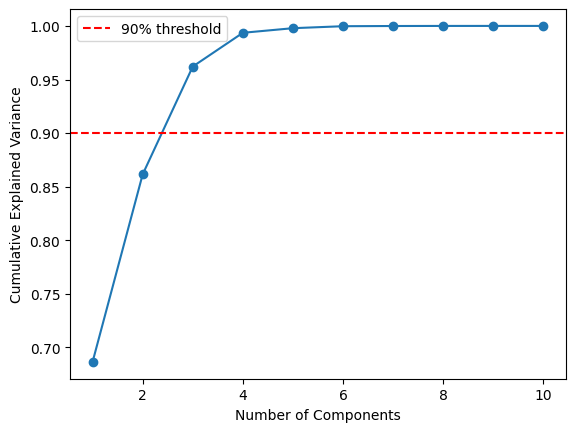

In [35]:
pca_full = PCA().fit(X_scaled)

plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
         np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.axhline(0.90, color='red', linestyle='--', label='90% threshold')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.show()

In [36]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=behavior_features.columns,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)
pca_loadings.sort_values('PC1', key=abs, ascending=False)

,PC1,PC2,PC3
mean_load,0.377356,-0.002069,0.146539
night_mean,0.377206,-0.063175,0.115597
weekend_mean,0.377000,-0.071191,0.115325
weekday_mean,0.376657,0.017522,0.155656
day_mean,0.374556,0.048116,0.173658
load_std,0.367558,0.130896,-0.147781
peak_load,0.360582,0.129686,-0.211810
load_factor,-0.108649,-0.361601,0.825780
weekend_weekday_ratio,0.090700,-0.637387,-0.271423
day_night_ratio,-0.076659,0.646022,0.274211


## 7. K-Means Clustering

The number of clusters is chosen using both the elbow method and the silhouette score.

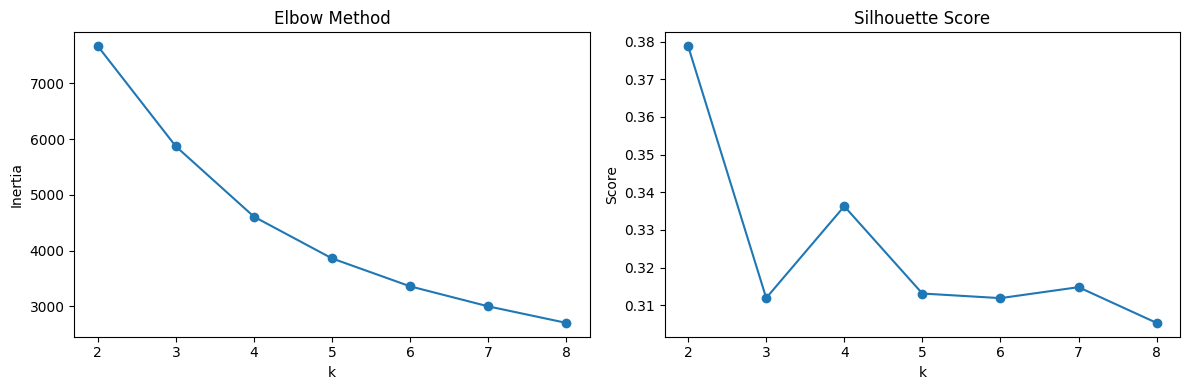

In [37]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia, sil = [], []
K = range(2, 9)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_pca, labels))

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(K, inertia, marker='o'); ax[0].set_title("Elbow Method"); ax[0].set_xlabel("k"); ax[0].set_ylabel("Inertia")
ax[1].plot(K, sil, marker='o'); ax[1].set_title("Silhouette Score"); ax[1].set_xlabel("k"); ax[1].set_ylabel("Score")
plt.tight_layout()
plt.show()

In [38]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

building_features['cluster'] = clusters
print("Silhouette score (k=4):", silhouette_score(X_pca, clusters))
building_features['cluster'].value_counts().sort_index()

Silhouette score (k=4): 0.3362807400664774


cluster
0    345
1    640
2    316
3    148
Name: count, dtype: int64

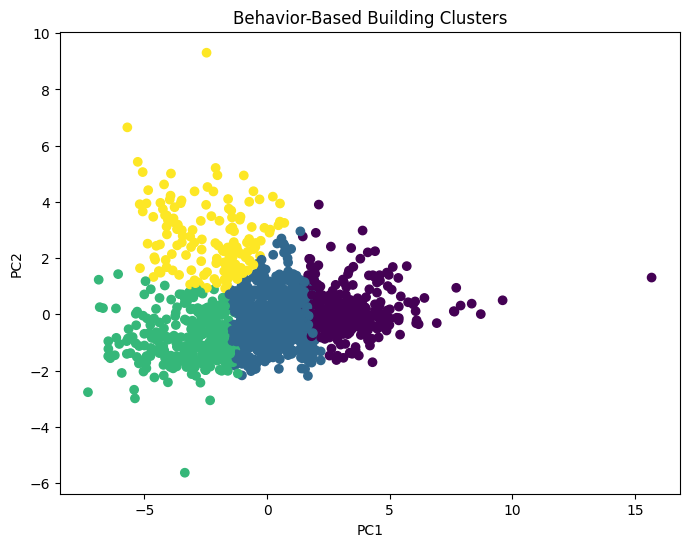

In [39]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Behavior-Based Building Clusters")
plt.show()

## 8. Cluster Profiling

In [40]:
building_features = building_features.join(building_temp_sens)
cluster_profile = building_features.groupby('cluster').mean()
cluster_profile

,mean_load,peak_load,load_std,square_feet,load_factor,day_mean,night_mean,weekend_mean,weekday_mean,day_night_ratio,weekend_weekday_ratio,temp_sensitivity
cluster,,,,,,,,,,,,
0,6.514500,8.700493,6.551409,183825.956522,0.163469,6.583243,6.441964,6.447164,6.538309,1.180219,0.919223,0.050281
1,4.713992,6.074814,4.092815,86282.200000,0.339923,4.809722,4.612543,4.613246,4.749313,1.251745,0.879657,0.235222
2,2.559555,3.554643,1.875887,24171.610759,0.373697,2.589624,2.521243,2.504280,2.579039,1.112525,0.927031,0.182739
3,3.162336,4.750034,3.048668,48589.000000,0.225110,3.492357,2.740154,2.644090,3.306094,2.352368,0.505551,-0.009732


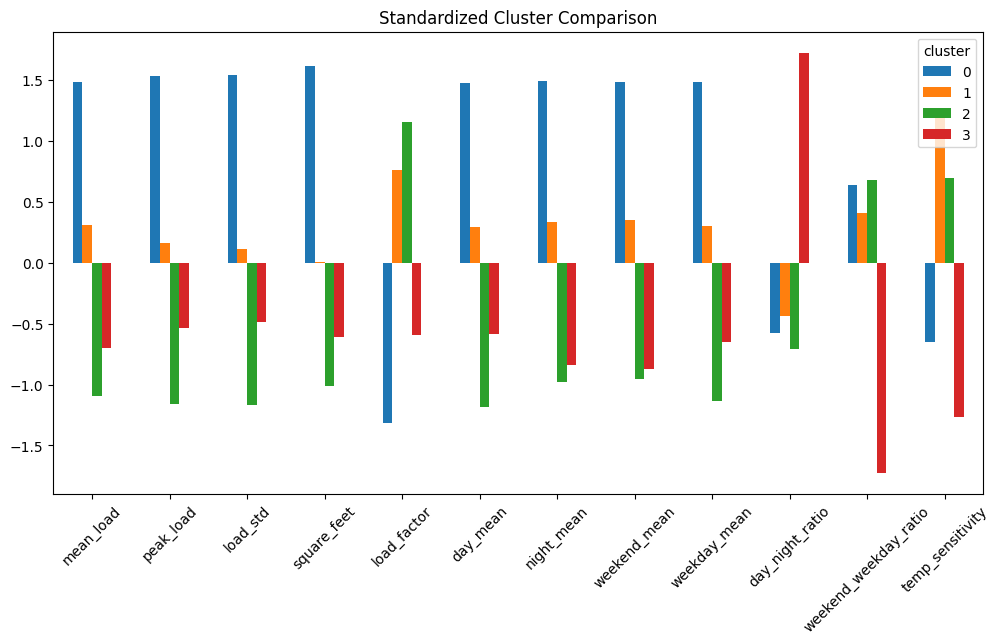

In [41]:
scaled_profile = pd.DataFrame(
    StandardScaler().fit_transform(cluster_profile),
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

scaled_profile.T.plot(kind='bar', figsize=(12,6))
plt.title("Standardized Cluster Comparison")
plt.xticks(rotation=45)
plt.show()

In [42]:
train_clustered = train2.merge(
    building_features[['cluster']],
    left_on='building_id',
    right_index=True,
    how='left'
)
hourly_cluster = (
    train_clustered
    .groupby(['cluster', 'hour'])['meter_reading']
    .mean()
    .reset_index()
)

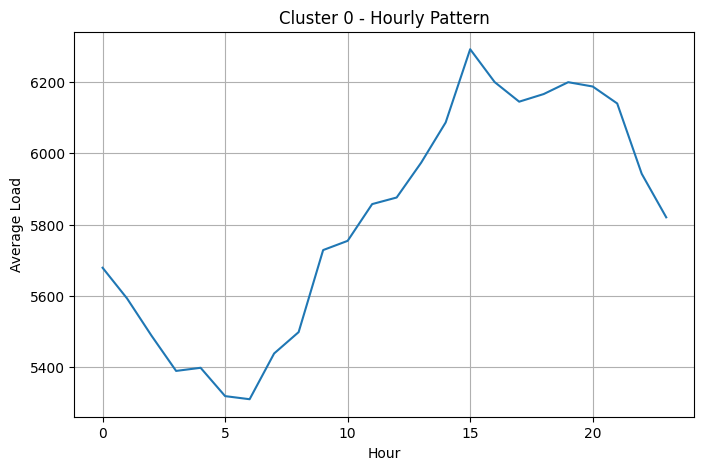

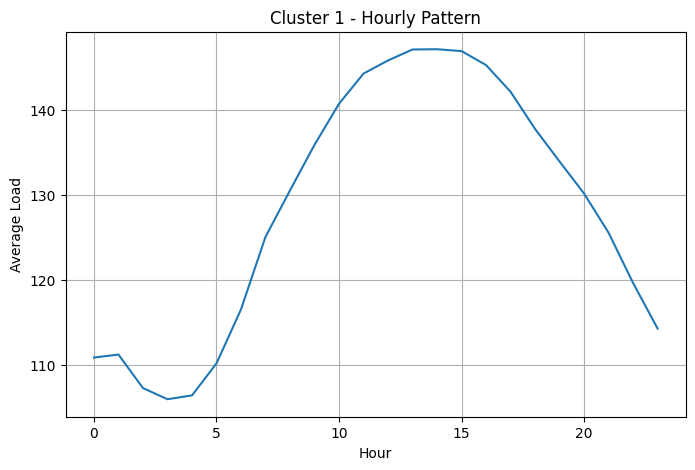

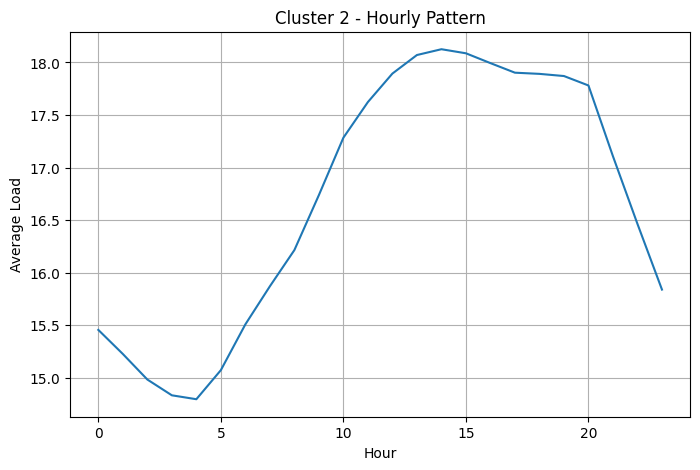

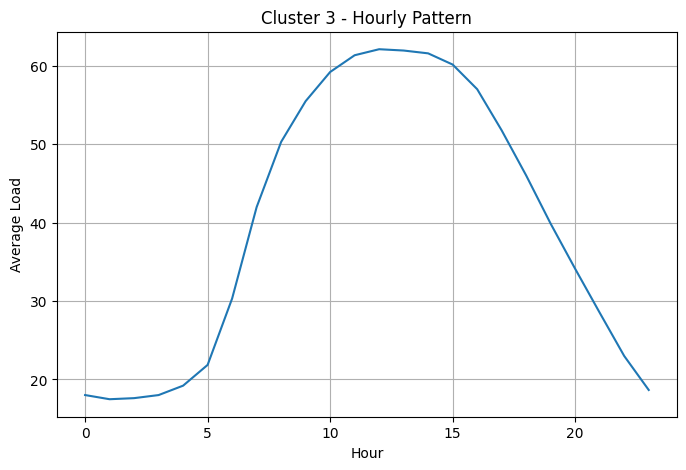

In [43]:
for c in sorted(hourly_cluster['cluster'].unique()):
    plt.figure(figsize=(8,5))
    
    cluster_data = hourly_cluster[hourly_cluster['cluster'] == c]
    plt.plot(cluster_data['hour'], cluster_data['meter_reading'])
    
    plt.xlabel("Hour")
    plt.ylabel("Average Load")
    plt.title(f"Cluster {c} - Hourly Pattern")
    plt.grid(True)
    plt.show()

In [44]:
peak_cluster = (
    train_clustered
    .groupby('cluster')['meter_reading']
    .max()
    .reset_index()
)

peak_cluster

,cluster,meter_reading
0,0,2.190470e+07
1,1,2.479350e+04
2,2,4.172740e+02
3,3,4.457920e+03


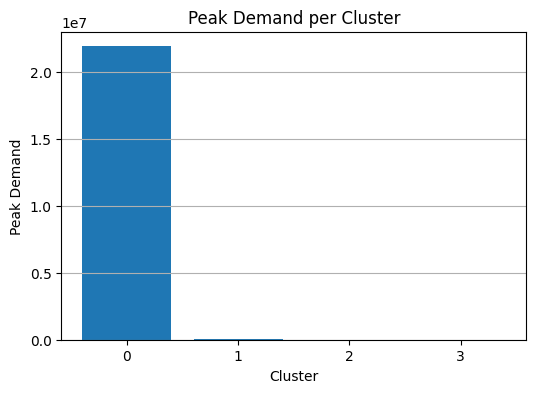

In [45]:
plt.figure(figsize=(6,4))

plt.bar(peak_cluster['cluster'],
        peak_cluster['meter_reading'])

plt.xlabel("Cluster")
plt.ylabel("Peak Demand")
plt.title("Peak Demand per Cluster")
plt.xticks(peak_cluster['cluster'])
plt.grid(axis='y')
plt.show()

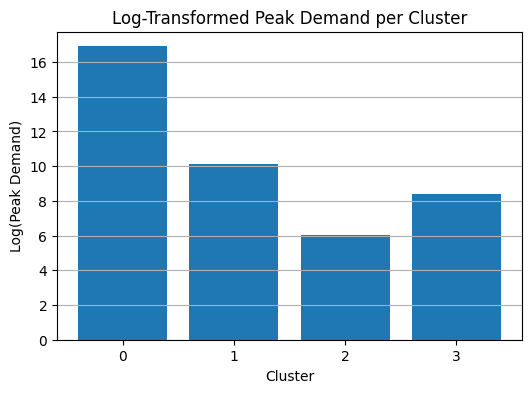

In [46]:
import numpy as np

peak_cluster['log_peak'] = np.log1p(peak_cluster['meter_reading'])

plt.figure(figsize=(6,4))

plt.bar(peak_cluster['cluster'],
        peak_cluster['log_peak'])

plt.xlabel("Cluster")
plt.ylabel("Log(Peak Demand)")
plt.title("Log-Transformed Peak Demand per Cluster")
plt.xticks(peak_cluster['cluster'])
plt.grid(axis='y')
plt.show()

In [47]:
weekend_weekday = (
    train_clustered
    .groupby(['cluster', 'is_weekend'])['meter_reading']
    .mean()
    .unstack()
)

weekend_weekday.columns = ['Weekday', 'Weekend']
weekend_weekday

,Weekday,Weekend
cluster,,
0,6115.392268,5055.403768
1,132.871318,117.263014
2,17.086792,15.712287
3,46.226425,23.883804


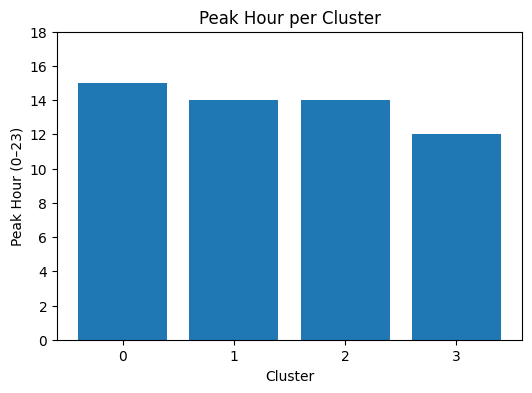

In [48]:
hourly_cluster_avg = (
    train_clustered
    .groupby(['cluster', 'hour'])['meter_reading']
    .mean()
    .reset_index()
)
peak_hour_cluster = (
    hourly_cluster_avg
    .loc[hourly_cluster_avg.groupby('cluster')['meter_reading'].idxmax()]
    .reset_index(drop=True)
)
peak_hour_cluster = peak_hour_cluster.rename(columns={
    'hour': 'Peak Hour',
    'meter_reading': 'Average Load at Peak Hour'
})

peak_hour_cluster

plt.figure(figsize=(6,4))

plt.bar(peak_hour_cluster['cluster'],
        peak_hour_cluster['Peak Hour'])

plt.xlabel("Cluster")
plt.ylabel("Peak Hour (0–23)")
plt.title("Peak Hour per Cluster")

plt.ylim(0, 18) 
plt.xticks(peak_hour_cluster['cluster'])

plt.show()

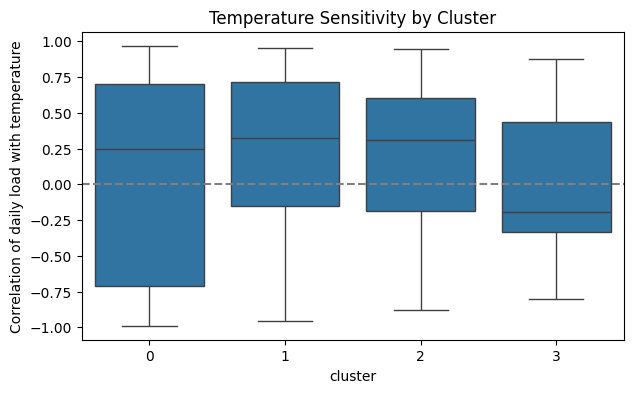

In [49]:
# Temperature sensitivity by cluster
plt.figure(figsize=(7,4))
sns.boxplot(data=building_features.reset_index(), x='cluster', y='temp_sensitivity')
plt.axhline(0, color='grey', linestyle='--')
plt.title("Temperature Sensitivity by Cluster")
plt.ylabel("Correlation of daily load with temperature")
plt.show()

### Average sensitivity hides heating vs cooling buildings cancelling out, so absolute sensitivity and counts per cluster are used instead.

In [50]:
building_features['abs_temp_sens'] = building_features['temp_sensitivity'].abs()
building_features['weather_type'] = pd.cut(building_features['temp_sensitivity'],
                                           bins=[-1, -0.5, 0.5, 1],
                                           labels=['Heating-driven', 'Weak/none', 'Cooling-driven'])
print(building_features.groupby('cluster')['abs_temp_sens'].mean().round(3))
print()
print(pd.crosstab(building_features['cluster'], building_features['weather_type']))

cluster
0    0.627
1    0.507
2    0.459
3    0.365
Name: abs_temp_sens, dtype: float64

weather_type  Heating-driven  Weak/none  Cooling-driven
cluster                                                
0                        108        109             128
1                         75        297             268
2                         38        169             109
3                          5        116              27


## 9. Insights for Energy Optimization

**Overall pattern:** Average weekend consumption is **~17% lower** than weekday consumption across all 1,449 buildings, confirming that occupancy schedules strongly influence energy use.

**Weather:** Outdoor temperature is a major driver of consumption. **532 buildings (37%)** are strongly cooling-driven (ρ > 0.5) and **226 (16%)** are strongly heating-driven (ρ < −0.5), so over half of all buildings are highly temperature-dependent. Because heating- and cooling-driven buildings cancel each other out when averaged, temperature sensitivity is compared across clusters using its **absolute value**.

**Model summary:** PCA reduced 10 behavioral features to 3 components retaining **96% of the variance**. K-Means with k = 4 produced a silhouette score of **0.34**, indicating moderate but meaningful cluster separation.

**Cluster 0 – Large, peaky, highly weather-dependent (345 buildings)**
Largest buildings (~184k sq ft avg) with the highest consumption and the **lowest load factor (0.16)**. They are also the **most temperature-sensitive group (|ρ| = 0.63)**, with a near-even split of heating-driven (108) and cooling-driven (128) buildings, consistent with large facilities running both heating and cooling systems.
**Opportunity:** Peak shaving, load shifting, and weather-based HVAC control; the largest absolute savings potential.

**Cluster 1 – Mid-size, cooling-dominant (640 buildings)**
Mid-sized buildings (~86k sq ft) with high temperature sensitivity (|ρ| = 0.51). Of the strongly temperature-dependent buildings in this group, **cooling-driven ones outnumber heating-driven ones roughly 3.5 to 1 (268 vs 75)**.
**Opportunity:** Pre-cooling strategies, cooling-system efficiency upgrades, and weather-based demand forecasting.

**Cluster 2 – Small, steady base-load buildings (316 buildings)**
Smallest buildings (~24k sq ft) with the **highest load factor (0.37)** and only an ~8% weekend drop, i.e. flat, continuous consumption. Most (169 of 316) show weak temperature dependence.
**Opportunity:** Scheduling offers little gain; savings come from efficient equipment and reducing always-on base load.

**Cluster 3 – Schedule-driven buildings (148 buildings)**
Daytime consumption is **2.35× nighttime** and weekend load is **~48% lower** than weekday, a typical office or school pattern. This is the **least weather-sensitive group (|ρ| = 0.37)**, with 116 of 148 buildings showing weak temperature dependence: occupancy, not weather, drives their consumption.
**Opportunity:** Automated HVAC and lighting setback during nights and weekends; the strongest candidate for occupancy-based control.

## Limitations
- All meter types (electricity, chilled water, steam, hot water) are combined into one reading; analysing each meter type separately would give cleaner profiles.
- PC1 loads almost equally on all load-level features, so part of the clustering reflects overall consumption magnitude (visible in Cluster 0 vs Cluster 2).
- A silhouette score of 0.34 indicates overlapping clusters; building behavior is a continuum rather than sharply separated groups.

